In [10]:
!pip install tensorflow shap

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

import shap

In [13]:
train = pd.read_csv("train_FD002[1].txt", sep=r"\s+", header=None)
test = pd.read_csv("test_FD002[1].txt", sep=r"\s+", header=None)
rul = pd.read_csv("RUL_FD002[1].txt", header=None)

In [14]:
import os
print(os.listdir())

['.config', 'RUL_FD002[1].txt', 'drive', 'test_FD002[1].txt', 'train_FD002[1].txt', '.ipynb_checkpoints', 'sample_data']


In [15]:
cols = ['engine_id','cycle','op1','op2','op3']
sensor_cols = ['s'+str(i) for i in range(1,22)]

all_cols = cols + sensor_cols

train.columns = all_cols
test.columns = all_cols

In [16]:
print(train.shape)
train.head()

(53759, 26)


,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286


In [17]:
max_cycle = train.groupby('engine_id')['cycle'].max().reset_index()

max_cycle.columns = ['engine_id','max_cycle']

train = train.merge(max_cycle,on='engine_id')

train['RUL'] = train['max_cycle'] - train['cycle']

train.drop('max_cycle',axis=1,inplace=True)

In [18]:
scaler = MinMaxScaler()

features = train.columns[2:-1]

train[features] = scaler.fit_transform(train[features])
test[features] = scaler.transform(test[features])

In [19]:
sequence_length = 30

def create_sequences(data, seq_length):

    X=[]
    y=[]

    for engine in data['engine_id'].unique():

        engine_data = data[data['engine_id']==engine]

        for i in range(len(engine_data)-seq_length):

            seq = engine_data.iloc[i:i+seq_length][features].values
            label = engine_data.iloc[i+seq_length]['RUL']

            X.append(seq)
            y.append(label)

    return np.array(X),np.array(y)

X_train,y_train = create_sequences(train,sequence_length)

In [20]:
print(X_train.shape)
print(y_train.shape)

(45959, 30, 24)
(45959,)


In [21]:
model = Sequential()

model.add(Conv1D(
    filters=64,
    kernel_size=3,
    activation='relu',
    input_shape=(sequence_length,len(features))
))

model.add(MaxPooling1D(pool_size=2))

model.add(LSTM(100))

model.add(Dropout(0.3))

model.add(Dense(50,activation='relu'))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [23]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 7337.8032 - val_loss: 3800.6692
Epoch 2/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 3909.4299 - val_loss: 3800.7080
Epoch 3/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 3863.9727 - val_loss: 3799.2954
Epoch 4/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 3901.9404 - val_loss: 3803.4517
Epoch 5/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 3907.0234 - val_loss: 3799.2910
Epoch 6/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 3904.5576 - val_loss: 3800.8059
Epoch 7/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 3895.3655 - val_loss: 3799.2729
Epoch 8/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 3893.3101 - val_loss: 3799.3250
Epoch 9/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 3888.7581 - val_loss: 3766.9683
Epoch 10/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 3616.1299 - val_loss: 2546.3467
Epoch 11/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 2337.

In [29]:
X_test=[]
y_true_for_pred=[]

for engine in test['engine_id'].unique():

    engine_data = test[test['engine_id']==engine]


    if len(engine_data) >= sequence_length:
        seq = engine_data.iloc[-sequence_length:][features].values
        X_test.append(seq)

        true_rul_value = rul.iloc[engine - 1][0]
        y_true_for_pred.append(true_rul_value)

X_test = np.array(X_test)
y_true_for_pred = np.array(y_true_for_pred)

In [31]:
pred = model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [32]:
rmse = np.sqrt(mean_squared_error(y_true_for_pred,pred))

print("RMSE:",rmse)

RMSE: 33.42464158430218


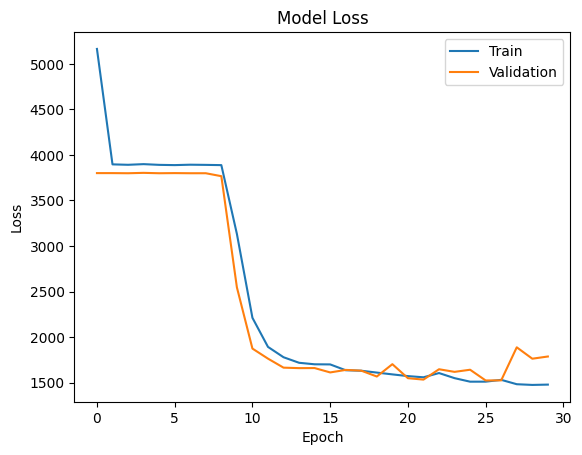

In [33]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()